In [2]:
import subprocess
subprocess.run(["pip", "install", "fredapi", "openpyxl", "sqlalchemy", "seaborn"], check=True)

CompletedProcess(args=['pip', 'install', 'fredapi', 'openpyxl', 'sqlalchemy', 'seaborn'], returncode=0)

In [4]:
import pandas
import requests
import matplotlib
print("All libraries ready!")

All libraries ready!


In [10]:
# ============================================
# SUPPLY CHAIN DISRUPTION ANALYZER
# Step 1: Pull real data from FRED API
# ============================================

import pandas as pd
from fredapi import Fred
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# Your API key
fred = Fred(api_key='e7f9c024e52a5b9578baee2b36d08469')

print("Connecting to FRED API...")

# ---- PULL 4 KEY DATASETS (with delay between each) ----

# 1. Crude Oil Prices
oil = fred.get_series('DCOILWTICO', observation_start='2018-01-01')
oil = oil.dropna()
print(f"✅ Oil prices pulled: {len(oil)} records")
time.sleep(2)  # wait 2 seconds before next request

# 2. Producer Price Index
ppi = fred.get_series('PPIACO', observation_start='2018-01-01')
ppi = ppi.dropna()
print(f"✅ Producer Price Index pulled: {len(ppi)} records")
time.sleep(2)

# 3. Consumer Price Index
cpi = fred.get_series('CPIAUCSL', observation_start='2018-01-01')
cpi = cpi.dropna()
print(f"✅ Consumer Price Index pulled: {len(cpi)} records")
time.sleep(2)

# 4. US Imports
imports = fred.get_series('IMPGS', observation_start='2018-01-01')
imports = imports.dropna()
print(f"✅ US Imports pulled: {len(imports)} records")
time.sleep(2)

# 5. Unemployment Rate
unemployment = fred.get_series('UNRATE', observation_start='2018-01-01')
unemployment = unemployment.dropna()
print(f"✅ Unemployment Rate pulled: {len(unemployment)} records")

print("\n🎉 All data pulled successfully!")
print(f"\nSample oil price data:")
print(oil.tail())

Connecting to FRED API...
✅ Oil prices pulled: 2098 records
✅ Producer Price Index pulled: 100 records
✅ Consumer Price Index pulled: 99 records
✅ US Imports pulled: 33 records
✅ Unemployment Rate pulled: 99 records

🎉 All data pulled successfully!

Sample oil price data:
2026-05-19    112.09
2026-05-20    101.69
2026-05-21    100.20
2026-05-22    100.35
2026-05-26     97.63
dtype: float64


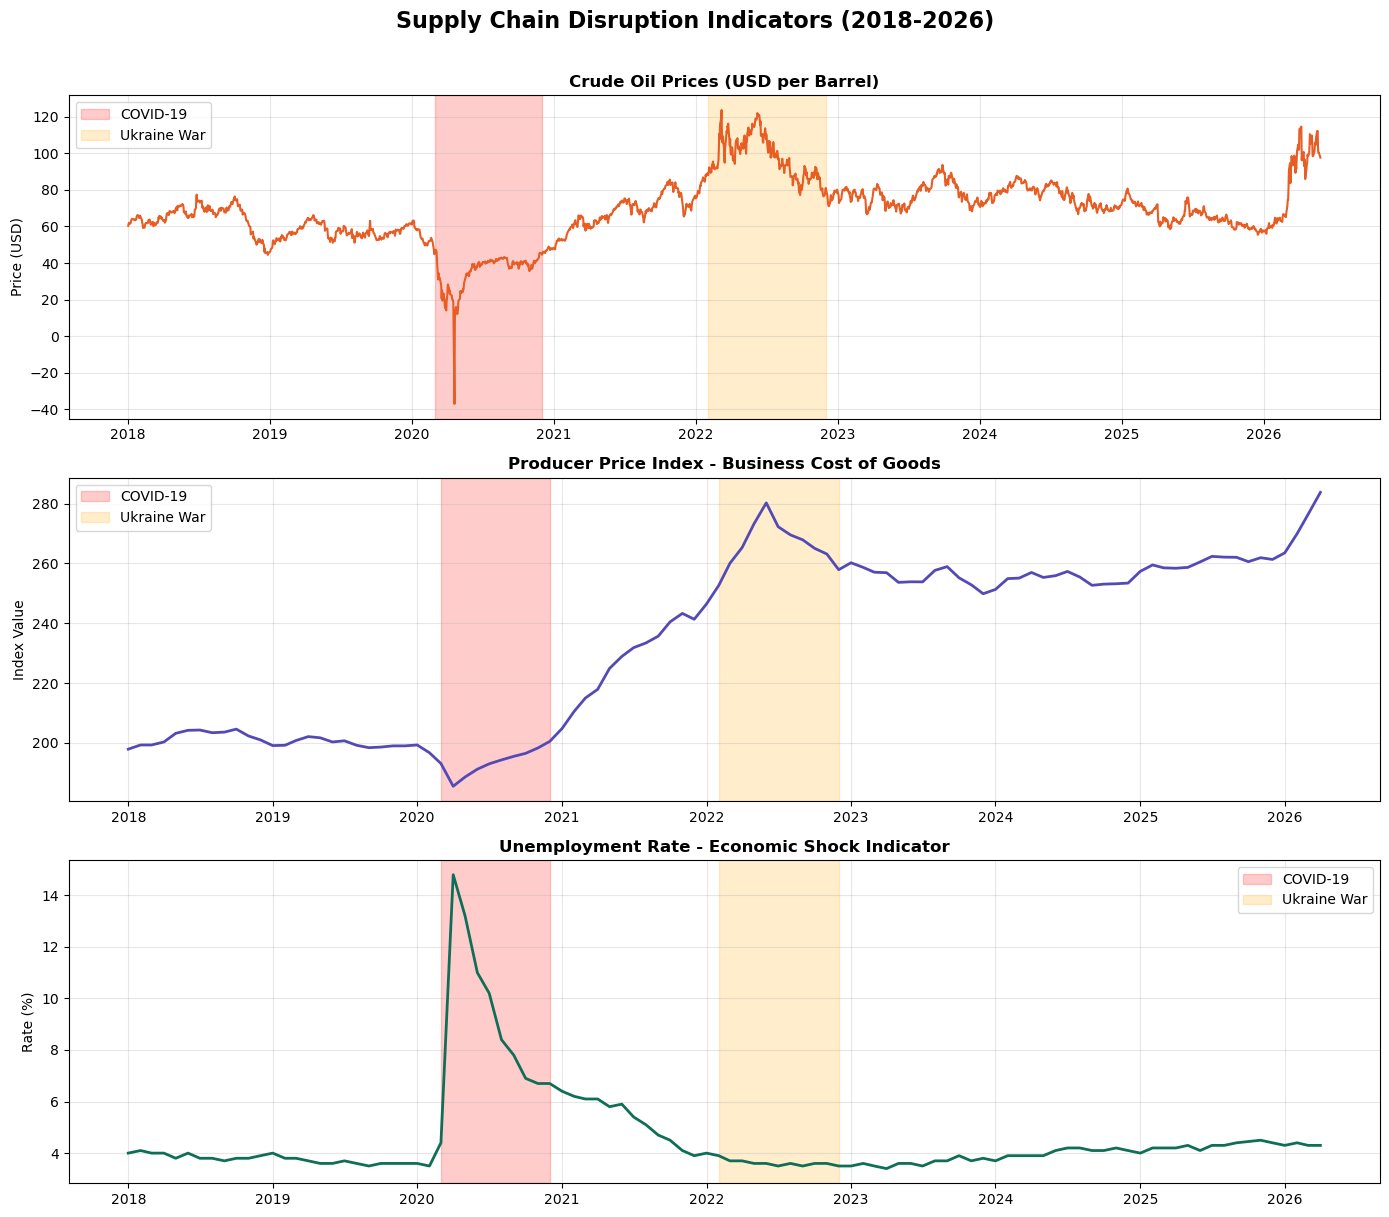

✅ Chart saved as supply_chain_overview.png


In [12]:
# ============================================
# Step 2: Visualize the data
# ============================================

fig, axes = plt.subplots(3, 1, figsize=(14, 12))
fig.suptitle('Supply Chain Disruption Indicators (2018-2026)', 
             fontsize=16, fontweight='bold', y=1.01)

# --- Chart 1: Oil Prices ---
axes[0].plot(oil.index, oil.values, color='#E85D24', linewidth=1.5)
axes[0].axvspan('2020-03-01', '2020-12-01', alpha=0.2, color='red', label='COVID-19')
axes[0].axvspan('2022-02-01', '2022-12-01', alpha=0.2, color='orange', label='Ukraine War')
axes[0].set_title('Crude Oil Prices (USD per Barrel)', fontweight='bold')
axes[0].set_ylabel('Price (USD)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Chart 2: Producer Price Index ---
axes[1].plot(ppi.index, ppi.values, color='#534AB7', linewidth=2)
axes[1].axvspan('2020-03-01', '2020-12-01', alpha=0.2, color='red', label='COVID-19')
axes[1].axvspan('2022-02-01', '2022-12-01', alpha=0.2, color='orange', label='Ukraine War')
axes[1].set_title('Producer Price Index - Business Cost of Goods', fontweight='bold')
axes[1].set_ylabel('Index Value')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Chart 3: Unemployment Rate ---
axes[2].plot(unemployment.index, unemployment.values, color='#0F6E56', linewidth=2)
axes[2].axvspan('2020-03-01', '2020-12-01', alpha=0.2, color='red', label='COVID-19')
axes[2].axvspan('2022-02-01', '2022-12-01', alpha=0.2, color='orange', label='Ukraine War')
axes[2].set_title('Unemployment Rate - Economic Shock Indicator', fontweight='bold')
axes[2].set_ylabel('Rate (%)')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('supply_chain_overview.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Chart saved as supply_chain_overview.png")

In [14]:
# ============================================
# Step 3: Build the Risk Score Model
# ============================================

import numpy as np

# --- Resample everything to monthly so they align ---
oil_monthly = oil.resample('MS').mean()
ppi_monthly = ppi.resample('MS').mean()
cpi_monthly = cpi.resample('MS').mean()
unemployment_monthly = unemployment.resample('MS').mean()

# --- Combine all into one dataframe ---
df = pd.DataFrame({
    'oil_price': oil_monthly,
    'ppi': ppi_monthly,
    'cpi': cpi_monthly,
    'unemployment': unemployment_monthly
})

df = df.dropna()
print(f"✅ Combined dataset: {len(df)} months of data")
print(df.head())

# --- Normalize each indicator (0 to 100 scale) ---
def normalize(series):
    return ((series - series.min()) / (series.max() - series.min())) * 100

df['oil_score']          = normalize(df['oil_price'])
df['ppi_score']          = normalize(df['ppi'])
df['cpi_score']          = normalize(df['cpi'])
df['unemployment_score'] = normalize(df['unemployment'])

# --- Calculate overall Disruption Risk Score ---
# Weights: Oil 30%, PPI 25%, CPI 25%, Unemployment 20%
df['risk_score'] = (
    df['oil_score']          * 0.30 +
    df['ppi_score']          * 0.25 +
    df['cpi_score']          * 0.25 +
    df['unemployment_score'] * 0.20
)

print("\n✅ Risk scores calculated!")
print("\nTop 5 highest risk months:")
print(df['risk_score'].nlargest(5))

print("\nTop 5 lowest risk months:")
print(df['risk_score'].nsmallest(5))

✅ Combined dataset: 99 months of data
            oil_price    ppi      cpi  unemployment
2018-01-01  63.698571  197.9  248.859           4.0
2018-02-01  62.229474  199.3  249.529           4.1
2018-03-01  62.724762  199.3  249.577           4.0
2018-04-01  66.253810  200.3  250.227           4.0
2018-05-01  69.978182  203.2  250.792           3.8

✅ Risk scores calculated!

Top 5 highest risk months:
2026-04-01    77.146997
2026-03-01    71.919444
2022-06-01    68.250978
2022-05-01    63.762163
2022-07-01    61.998441
Name: risk_score, dtype: float64

Top 5 lowest risk months:
2020-03-01    10.310076
2018-12-01    16.054741
2019-01-01    16.250701
2020-02-01    16.510178
2019-02-01    17.244473
Name: risk_score, dtype: float64


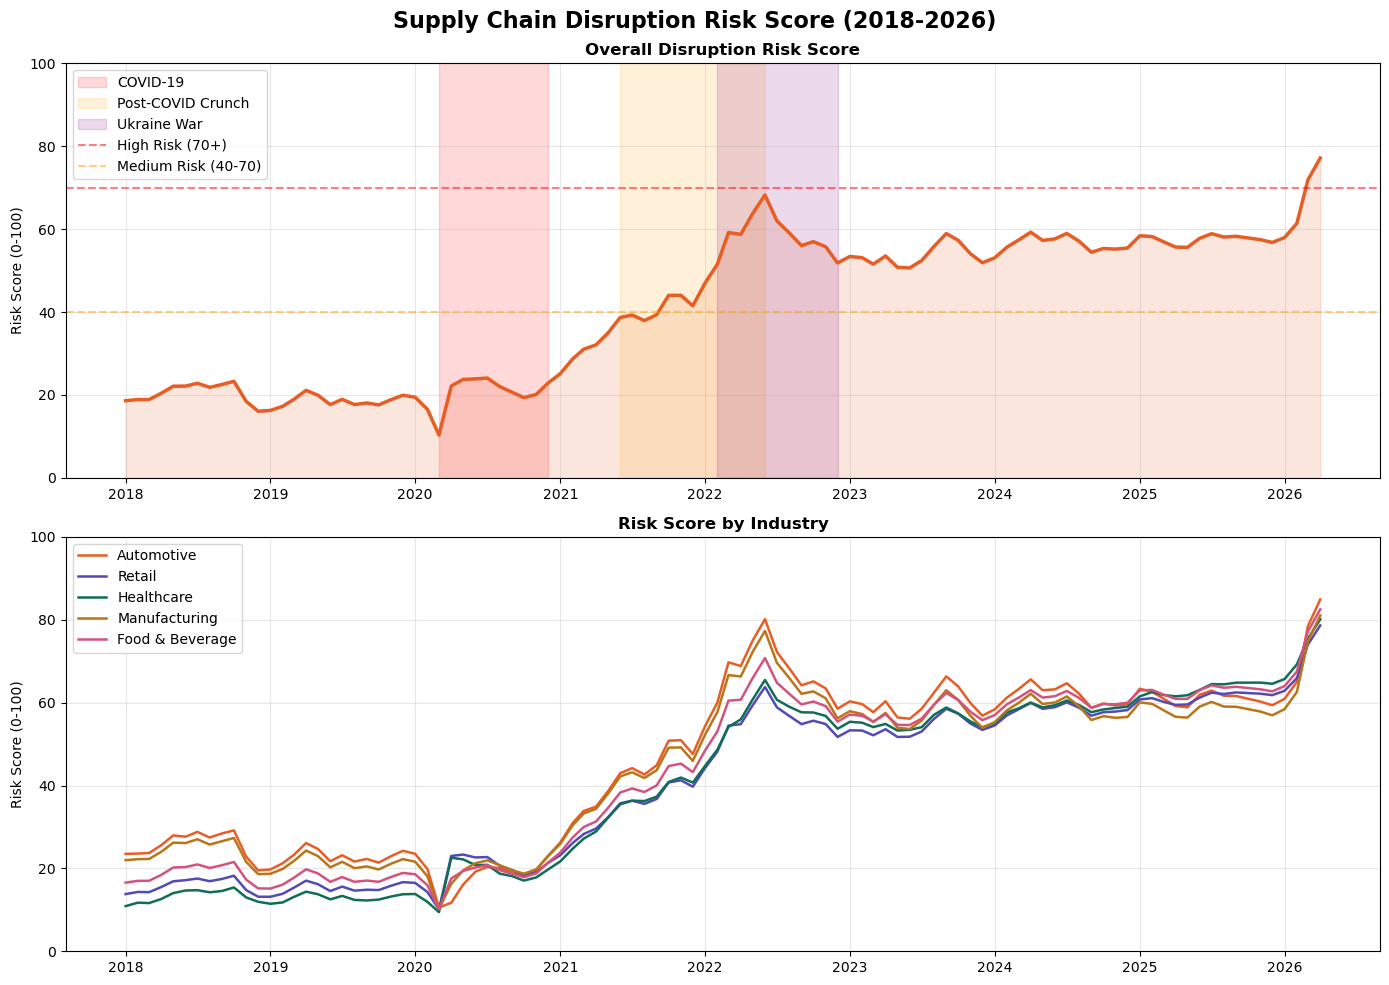

✅ Risk score chart saved!

--- Industry Risk Summary (Latest Month) ---
                 Current Risk Score
Automotive                     84.9
Retail                         78.6
Healthcare                     80.1
Manufacturing                  81.0
Food & Beverage                82.5


In [18]:
# ============================================
# Step 4: Visualize the Risk Score
# ============================================

import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Supply Chain Disruption Risk Score (2018-2026)', 
             fontsize=16, fontweight='bold')

# --- Chart 1: Risk Score Over Time ---
axes[0].plot(df.index, df['risk_score'], color='#E85D24', linewidth=2.5)
axes[0].fill_between(df.index, df['risk_score'], alpha=0.15, color='#E85D24')

# Mark disruption events using proper datetime
axes[0].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2020-12-01'), 
                alpha=0.15, color='red', label='COVID-19')
axes[0].axvspan(pd.Timestamp('2021-06-01'), pd.Timestamp('2022-06-01'), 
                alpha=0.15, color='orange', label='Post-COVID Crunch')
axes[0].axvspan(pd.Timestamp('2022-02-01'), pd.Timestamp('2022-12-01'), 
                alpha=0.15, color='purple', label='Ukraine War')

# Risk level lines
axes[0].axhline(y=70, color='red', linestyle='--', alpha=0.5, label='High Risk (70+)')
axes[0].axhline(y=40, color='orange', linestyle='--', alpha=0.5, label='Medium Risk (40-70)')

axes[0].set_title('Overall Disruption Risk Score', fontweight='bold')
axes[0].set_ylabel('Risk Score (0-100)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(0, 100)

# --- Chart 2: Risk Score by Industry ---
industry_weights = {
    'Automotive':     {'oil': 0.40, 'ppi': 0.30, 'cpi': 0.20, 'unemployment': 0.10},
    'Retail':         {'oil': 0.20, 'ppi': 0.25, 'cpi': 0.35, 'unemployment': 0.20},
    'Healthcare':     {'oil': 0.10, 'ppi': 0.40, 'cpi': 0.30, 'unemployment': 0.20},
    'Manufacturing':  {'oil': 0.35, 'ppi': 0.35, 'cpi': 0.15, 'unemployment': 0.15},
    'Food & Beverage':{'oil': 0.25, 'ppi': 0.30, 'cpi': 0.30, 'unemployment': 0.15},
}

industry_scores = {}
for industry, weights in industry_weights.items():
    industry_scores[industry] = (
        df['oil_score']          * weights['oil'] +
        df['ppi_score']          * weights['ppi'] +
        df['cpi_score']          * weights['cpi'] +
        df['unemployment_score'] * weights['unemployment']
    )

industry_df = pd.DataFrame(industry_scores)

colors = ['#E85D24', '#534AB7', '#0F6E56', '#BA7517', '#D4537E']
for col, color in zip(industry_df.columns, colors):
    axes[1].plot(industry_df.index, industry_df[col], 
                 linewidth=1.8, label=col, color=color)

axes[1].set_title('Risk Score by Industry', fontweight='bold')
axes[1].set_ylabel('Risk Score (0-100)')
axes[1].legend(loc='upper left')
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig('risk_score_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Risk score chart saved!")
print("\n--- Industry Risk Summary (Latest Month) ---")
print(industry_df.tail(1).T.rename(
    columns={industry_df.index[-1]: 'Current Risk Score'}).round(1))

In [20]:
# ============================================
# Step 5: Save data for Tableau Dashboard
# ============================================

# --- Save main dataframe to CSV ---
df_export = df.copy()
df_export.index.name = 'date'
df_export.reset_index(inplace=True)
df_export.to_csv('supply_chain_main.csv', index=False)
print("✅ Main data saved: supply_chain_main.csv")

# --- Save industry scores to CSV ---
industry_export = industry_df.copy()
industry_export.index.name = 'date'
industry_export.reset_index(inplace=True)
industry_export.to_csv('supply_chain_industry.csv', index=False)
print("✅ Industry data saved: supply_chain_industry.csv")

# --- Save combined Excel file (multiple sheets) ---
with pd.ExcelWriter('supply_chain_full_report.xlsx', engine='openpyxl') as writer:
    df_export.to_excel(writer, sheet_name='Main Indicators', index=False)
    industry_export.to_excel(writer, sheet_name='Industry Risk Scores', index=False)
    
    # Summary sheet
    summary = pd.DataFrame({
        'Metric': ['Highest Risk Month', 'Lowest Risk Month', 
                   'Average Risk Score', 'Current Risk Score',
                   'Most At-Risk Industry Today',
                   'Least At-Risk Industry Today'],
        'Value': [
            str(df['risk_score'].idxmax().strftime('%B %Y')),
            str(df['risk_score'].idxmin().strftime('%B %Y')),
            str(round(df['risk_score'].mean(), 1)),
            str(round(df['risk_score'].iloc[-1], 1)),
            str(industry_df.iloc[-1].idxmax()),
            str(industry_df.iloc[-1].idxmin()),
        ]
    })
    summary.to_excel(writer, sheet_name='Executive Summary', index=False)

print("✅ Excel report saved: supply_chain_full_report.xlsx")

print("\n========================================")
print("PROJECT FILES READY:")
print("========================================")
print("1. supply_chain_main.csv       → connect to Tableau")
print("2. supply_chain_industry.csv   → connect to Tableau")
print("3. supply_chain_full_report.xlsx → share with anyone")
print("4. supply_chain_overview.png   → charts")
print("5. risk_score_chart.png        → risk dashboard")
print("\n🎉 Python analysis complete!")
print("Next step: Open Tableau and connect these CSV files!")

✅ Main data saved: supply_chain_main.csv
✅ Industry data saved: supply_chain_industry.csv
✅ Excel report saved: supply_chain_full_report.xlsx

PROJECT FILES READY:
1. supply_chain_main.csv       → connect to Tableau
2. supply_chain_industry.csv   → connect to Tableau
3. supply_chain_full_report.xlsx → share with anyone
4. supply_chain_overview.png   → charts
5. risk_score_chart.png        → risk dashboard

🎉 Python analysis complete!
Next step: Open Tableau and connect these CSV files!


In [22]:
import os
print("Your files are located at:")
print(os.getcwd())

Your files are located at:
/Users/turpusaipriyareddy
